# Melanoma Phosphorylation — ProtT5 Pipeline

**Dataset:** LNCaP cells treated with ARi (CDK4/6 inhibitor)
**Task:** Binary classification — PTM-up (1) vs PTM-down (0)

**Model:** `Rostlab/prot_t5_xl_uniref50` (3B params, 1024-dim per-residue representations)

**Strategy:** Embed full protein sequences once, cache to disk, then slice
15-residue context windows around each phosphosite for classification.

**Tokenisation note:** ProtT5 (T5) adds only EOS at the end (no BOS).
After encoding, `hidden[j, :seq_len]` gives 0-based residue embeddings
that align directly with 0-based site indices derived from the `Site` column.

**Four classification heads:** MaxPool MLP, AttentionPool MLP, CenterOnly MLP, Hybrid MLP

**Publication plots:** 7 figures saved to `results_melanoma_phospho_prott5/` at 300 dpi

In [1]:
# ── 1. Imports & Setup ───────────────────────────────────────────────────────
from pathlib import Path
import hashlib
import random
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix,
    precision_score, recall_score, f1_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from transformers import T5Tokenizer, T5EncoderModel
from tqdm.auto import tqdm

# ── Publication style (mirrors EGFR / ESM2 pipelines) ────────────────────────
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi":        140,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "axes.titlesize":    13,
    "axes.labelsize":    12,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "legend.fontsize":   10,
    "savefig.bbox":      "tight",
    "savefig.dpi":       300,
})

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Paths ────────────────────────────────────────────────────────────────────
PDMAS_DIR     = Path("/home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response")
MELANOMA_DATA = PDMAS_DIR / "Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/Filtered_data_Melanoma_ARi_Phospho.csv"
RESULTS_DIR   = PDMAS_DIR / "Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EMBED_CACHE   = RESULTS_DIR / "prott5_full_protein_embeddings.npz"

import transformers
print(f"PyTorch device    : {device}")
print(f"Transformers ver  : {transformers.__version__}")
print(f"Melanoma data     : {MELANOMA_DATA.exists()} — {MELANOMA_DATA}")
print(f"Results dir       : {RESULTS_DIR}")
print(f"Embed cache       : {EMBED_CACHE.exists()} — {EMBED_CACHE}")

/home/saishyam/ankh_env/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch device    : cuda
Transformers ver  : 4.57.6
Melanoma data     : True — /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/Filtered_data_Melanoma_ARi_Phospho.csv
Results dir       : /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5
Embed cache       : False — /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/prott5_full_protein_embeddings.npz


In [2]:
# ── 2. Load & Clean Data / Assign Labels ─────────────────────────────────────
df = pd.read_csv(MELANOMA_DATA)
print(f"Loaded shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
display(df.head())

# Drop rows missing required fields
df_clean = df.dropna(subset=["Sequence", "Site_15mer", "Site", "PTM-regulation"]).copy()
print(f"After dropping NA: {df_clean.shape[0]} rows")

# PTM-up = 1, PTM-down = 0
df_clean["Class"] = df_clean["PTM-regulation"].map({"ptm-up": 1, "ptm-down": 0})
df_model = df_clean.dropna(subset=["Class"]).copy()
df_model["Class"] = df_model["Class"].astype(int)

counts = df_model["Class"].value_counts()
print(f"\nClass balance:")
print(f"  PTM-down (0): {counts.get(0, 0)}")
print(f"  PTM-up   (1): {counts.get(1, 0)}")
print(f"Rows for modeling: {len(df_model)}")

Loaded shape: (3200, 34)
Columns: ['ID', 'Version', 'PMID_sentenceIndex', 'PMID', 'Sentence', 'Protein_uniport', 'Protein', 'protein_entry', 'PTM', 'gene_manual', 'Site', 'species', 'Disease', 'Disease_fine', 'cell line', 'Drug_info', 'Drug', 'KW_info', 'KW', 'Pass', 'Note', 'Confidence score', 'Confidence level', 'Drug_class', 'Disease_category', 'Regulatory Class', 'Pattern', 'PTM-regulation', 'Disease-regulation', 'Status', 'Sequence', 'Site_15mer', 'Residue_Match', 'Actual_Residue']


,ID,Version,PMID_sentenceIndex,PMID,Sentence,Protein_uniport,Protein,protein_entry,PTM,gene_manual,...,Disease_category,Regulatory Class,Pattern,PTM-regulation,Disease-regulation,Status,Sequence,Site_15mer,Residue_Match,Actual_Residue
0,acc35607,202507,PRIDE title,PXD047335,ANDROGEN DRIVES MELANOMA INVASIVENESS AND META...,A0A2R8Y4L2,Heterogeneous nuclear ribonucleoprotein A1-like 3,RA1L3_HUMAN,phosphorylation,HNRNPA1L3,...,Cancer,Impairing,3,ptm-down,disease-good,Inferred,MSKSESPKEPEQLRKLFIGGLSFETTDESLRSHFEQWGTLTDCVVM...,____MSKSESPKEPE,True,S
1,acc35608,202507,PRIDE title,PXD047335,ANDROGEN DRIVES MELANOMA INVASIVENESS AND META...,P09651,Heterogeneous nuclear ribonucleoprotein A1,ROA1_HUMAN,phosphorylation,HNRNPA1,...,Cancer,Impairing,3,ptm-down,disease-good,Inferred,MSKSESPKEPEQLRKLFIGGLSFETTDESLRSHFEQWGTLTDCVVM...,____MSKSESPKEPE,True,S
2,acc35609,202507,PRIDE title,PXD047335,ANDROGEN DRIVES MELANOMA INVASIVENESS AND META...,A0JLT2,Mediator of RNA polymerase II transcription su...,MED19_HUMAN,phosphorylation,MED19,...,Cancer,Impairing,3,ptm-down,disease-good,Inferred,MENFTALFGAQADPPPPPTALGFGPGKPPPPPPPPAGGGPGTAPPP...,KKKKNRHSPDHPGMG,True,S
3,acc35610,202507,PRIDE title,PXD047335,ANDROGEN DRIVES MELANOMA INVASIVENESS AND META...,A0JNW5,Bridge-like lipid transfer protein family memb...,BLT3B_HUMAN,phosphorylation,BLTP3B,...,Cancer,Impairing,3,ptm-down,disease-good,Inferred,MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVL...,PLLFKSASDTNLQKG,True,S
4,acc35611,202507,PRIDE title,PXD047335,ANDROGEN DRIVES MELANOMA INVASIVENESS AND META...,A1L170,Uncharacterized protein C1orf226,CA226_HUMAN,phosphorylation,C1orf226,...,Cancer,Enhancing,3,ptm-up,disease-good,Inferred,MFENLNTALTPKLQASRSFPHLSKPVAPGSAPLGSGEPGGPGLWVG...,TECRRASSPSLIERN,True,S


After dropping NA: 3200 rows

Class balance:
  PTM-down (0): 1823
  PTM-up   (1): 1377
Rows for modeling: 3200


In [3]:
# ── 3. ProtT5 Full-Protein Embeddings (cached) ────────────────────────────────
# Model: Rostlab/prot_t5_xl_uniref50 — 3B params, 1024-dim
# T5 adds only EOS at the end (no BOS).
# After encoding: hidden[j, :seq_len] gives 0-based residue embeddings.
PROTT5_MODEL_NAME = "Rostlab/prot_t5_xl_uniref50"
PROTT5_MAX_LEN    = 1024   # total tokens including EOS
PROTT5_BATCH_SIZE = 1      # ProtT5-XL is ~3B parameters; keep at 1 to avoid OOM


def sequence_to_id(seq: str) -> str:
    return hashlib.md5(seq.encode()).hexdigest()


def preprocess_prott5(seq: str) -> str:
    """Space-separate amino acids; replace ambiguous residues (U/Z/O/B) with X."""
    seq = re.sub(r"[UZOB]", "X", seq.upper())
    return " ".join(list(seq))


@torch.no_grad()
def embed_proteins_prott5(seqs: list, model, tokenizer) -> dict:
    """
    Embed protein sequences with ProtT5.
    T5 adds only EOS at the end (no BOS).
    hidden[j, :seq_len] gives 0-based residue embeddings
    that align directly with 0-based site indices.
    Returns {md5_id: Tensor(L, 1024)} on CPU.
    """
    emb_dict = {}
    max_res = PROTT5_MAX_LEN - 1   # leave 1 slot for EOS
    for i in tqdm(range(0, len(seqs), PROTT5_BATCH_SIZE), desc="Embedding proteins (ProtT5)"):
        batch_seqs  = seqs[i:i + PROTT5_BATCH_SIZE]
        pids        = [sequence_to_id(s) for s in batch_seqs]
        batch_trunc  = [s[:max_res] for s in batch_seqs]
        batch_spaced = [preprocess_prott5(s) for s in batch_trunc]
        tokens = tokenizer(
            batch_spaced, return_tensors="pt",
            padding=True, truncation=True, max_length=PROTT5_MAX_LEN,
        ).to(device)
        out    = model(input_ids=tokens.input_ids, attention_mask=tokens.attention_mask)
        hidden = out.last_hidden_state   # (B, padded_L, 1024)
        for j, (pid, seq_trunc) in enumerate(zip(pids, batch_trunc)):
            seq_len = len(seq_trunc)           # number of residues (no EOS)
            emb_dict[pid] = hidden[j, :seq_len].cpu()   # (seq_len, 1024)
    return emb_dict


unique_seqs = df_model["Sequence"].drop_duplicates().tolist()
print(f"Unique proteins to embed: {len(unique_seqs)}")

if EMBED_CACHE.exists():
    print(f"Loading cached embeddings from {EMBED_CACHE} …")
    cache_data = np.load(EMBED_CACHE, allow_pickle=True)
    protein_embeddings = cache_data["embeddings"].item()
    print(f"Loaded {len(protein_embeddings)} embeddings from cache.")
else:
    print("Cache not found — running ProtT5 embedding (this will take a while) …")
    t0 = time.time()
    print(f"Loading {PROTT5_MODEL_NAME} …")
    prott5_tokenizer = T5Tokenizer.from_pretrained(PROTT5_MODEL_NAME, do_lower_case=False)
    prott5_model     = T5EncoderModel.from_pretrained(PROTT5_MODEL_NAME).to(device).eval()
    EMBED_DIM_TMP    = prott5_model.config.d_model
    print(f"ProtT5 loaded | embed_dim={EMBED_DIM_TMP}")
    protein_embeddings = embed_proteins_prott5(unique_seqs, prott5_model, prott5_tokenizer)
    elapsed = time.time() - t0
    print(f"Embedding complete in {elapsed:.1f}s | {len(protein_embeddings)} proteins")
    np.savez(EMBED_CACHE, embeddings=protein_embeddings)
    print(f"Embeddings cached to {EMBED_CACHE}")
    del prott5_model, prott5_tokenizer
    if device.type == "cuda":
        torch.cuda.empty_cache()

EMBED_DIM = next(iter(protein_embeddings.values())).shape[1]
print(f"Embedding dim: {EMBED_DIM}")

Unique proteins to embed: 1396
Cache not found — running ProtT5 embedding (this will take a while) …
Loading Rostlab/prot_t5_xl_uniref50 …


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


ProtT5 loaded | embed_dim=1024


Embedding proteins (ProtT5):   0%|                     | 0/1396 [00:00<?, ?it/s]

Embedding proteins (ProtT5):   0%|             | 1/1396 [00:00<04:11,  5.56it/s]

...

Embedding proteins (ProtT5): 100%|█████████▉| 1395/1396 [03:25<00:00,  6.99it/s]

Embedding proteins (ProtT5): 100%|██████████| 1396/1396 [03:25<00:00,  6.19it/s]

Embedding proteins (ProtT5): 100%|██████████| 1396/1396 [03:25<00:00,  6.80it/s]

Embedding complete in 213.9s | 1396 proteins


Embeddings cached to /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/prott5_full_protein_embeddings.npz
Embedding dim: 1024


In [4]:
# ── 4. 15-mer Window Extraction ───────────────────────────────────────────────
# Parse 1-indexed site number from Site column (e.g. "Ser445" → 445)
# 0-indexed center = site_num - 1
# window slice: [center-7 : center+8]  → exactly 15 residues
# ProtT5: hidden[j, :seq_len] already gives 0-based residue embeddings (no BOS).

def parse_site_number(site_str):
    if pd.isna(site_str):
        return None
    m = re.search(r'(\d+)', str(site_str))
    return int(m.group(1)) if m else None


df_model["site_num"]    = df_model["Site"].apply(parse_site_number)
df_model["win15_start"] = df_model["site_num"].apply(
    lambda n: (n - 1 - 7) if n is not None else np.nan)
df_model["win15_end"]   = df_model["site_num"].apply(
    lambda n: (n - 1 + 8) if n is not None else np.nan)   # exclusive end → 15 residues

print(f"Rows with valid site positions: {df_model['win15_start'].notna().sum()}/{len(df_model)}")


def build_window_dataset(df: pd.DataFrame, label: int, emb_dict: dict) -> tuple:
    """
    Slice 15-residue context window from full-protein ProtT5 embedding.
    win15_start / win15_end are 0-based (no BOS in ProtT5 embeddings).
    Slice: emb[s : e]  (e = s+15, exclusive).
    """
    X, y, kept = [], [], []
    skipped = {"no_site": 0, "no_emb": 0, "boundary": 0}
    for idx, row in df.iterrows():
        if pd.isna(row["win15_start"]):
            skipped["no_site"] += 1
            continue
        s, e = int(row["win15_start"]), int(row["win15_end"])
        pid  = sequence_to_id(row["Sequence"])
        if pid not in emb_dict:
            skipped["no_emb"] += 1
            continue
        emb = emb_dict[pid]          # Tensor (L, 1024)
        if s < 0 or e > emb.shape[0]:
            skipped["boundary"] += 1
            continue
        window = emb[s:e].numpy()    # (15, 1024)
        if window.shape[0] != 15:
            skipped["boundary"] += 1
            continue
        X.append(window)
        y.append(label)
        kept.append(idx)
    print(f"[label={label}] Extracted {len(X)} windows | "
          f"skipped: {skipped['no_site']} (no site), "
          f"{skipped['no_emb']} (no emb), {skipped['boundary']} (boundary)")
    return np.stack(X).astype(np.float32), np.array(y, dtype=int), kept


df_up   = df_model[df_model["Class"] == 1]
df_down = df_model[df_model["Class"] == 0]

X_pos, y_pos, _ = build_window_dataset(df_up,   1, protein_embeddings)
X_neg, y_neg, _ = build_window_dataset(df_down, 0, protein_embeddings)

X = np.concatenate([X_pos, X_neg], axis=0)   # (N, 15, 1024)
y = np.concatenate([y_pos, y_neg], axis=0)   # (N,)

print(f"\nCombined: X={X.shape}, y={y.shape}")
print(f"Class balance → PTM-up (1): {(y==1).sum()},  PTM-down (0): {(y==0).sum()}")
print(f"PR-AUC random baseline ≈ {(y==1).mean():.4f}")

Rows with valid site positions: 3200/3200
[label=1] Extracted 1068 windows | skipped: 0 (no site), 0 (no emb), 309 (boundary)


[label=0] Extracted 1452 windows | skipped: 0 (no site), 0 (no emb), 371 (boundary)



Combined: X=(2520, 15, 1024), y=(2520,)
Class balance → PTM-up (1): 1068,  PTM-down (0): 1452
PR-AUC random baseline ≈ 0.4238


In [5]:
# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f"Train : {X_train.shape}  pos={( y_train==1).sum()}  neg={(y_train==0).sum()}")
print(f"Test  : {X_test.shape}   pos={( y_test==1).sum()}   neg={(y_test==0).sum()}")
print(f"AUPRC random baseline (test) = {(y_test==1).mean():.4f}")

Train : (2016, 15, 1024)  pos=854  neg=1162
Test  : (504, 15, 1024)   pos=214   neg=290
AUPRC random baseline (test) = 0.4246


In [6]:
# ── 5. Classification Heads ────────────────────────────────────────────────────
class MaxPool(nn.Module):
    def forward(self, x):
        return x.max(dim=1).values


class AttentionPool(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn = nn.Linear(dim, 1)
    def forward(self, x):
        weights = F.softmax(self.attn(x).squeeze(-1), dim=1)
        return (x * weights.unsqueeze(-1)).sum(dim=1)


class PhosphoMLP(nn.Module):
    def __init__(self, pool: nn.Module, dim: int):
        super().__init__()
        self.pool = pool
        self.mlp  = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.mlp(self.pool(x)).squeeze(-1)


class CenterOnlyMLP(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        return self.net(x[:, 7, :]).squeeze(-1)


class HybridMLP(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.attn_pool  = AttentionPool(dim)
        self.classifier = nn.Sequential(
            nn.Linear(dim * 2, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128),     nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 1),
        )
    def forward(self, x):
        center  = x[:, 7, :]
        context = self.attn_pool(x)
        return self.classifier(torch.cat([center, context], dim=1)).squeeze(-1)


def train_and_eval(model, X_tr, y_tr, X_va, y_va,
                   epochs=20, lr=1e-3, batch_size=64):
    model = model.to(device)
    pos_weight = torch.tensor(
        (y_tr == 0).sum() / (y_tr == 1).sum(), dtype=torch.float32
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    loader = DataLoader(
        TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.float32),
        ), batch_size=batch_size, shuffle=True)
    val_X = torch.tensor(X_va, dtype=torch.float32).to(device)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(val_X)).cpu().numpy()
    return probs, roc_auc_score(y_va, probs), average_precision_score(y_va, probs)


print("All model classes and training helper defined.")

All model classes and training helper defined.


In [7]:
# ── Train All Models ──────────────────────────────────────────────────────────
D = EMBED_DIM   # 1024 for ProtT5-XL

models_to_train = {
    "MaxPool MLP":      PhosphoMLP(MaxPool(),        dim=D),
    "AttnPool MLP":     PhosphoMLP(AttentionPool(D), dim=D),
    "CenterOnly MLP":   CenterOnlyMLP(dim=D),
    "Hybrid (C+Attn)": HybridMLP(dim=D),
}
results = {}
for name, model in models_to_train.items():
    print(f"Training: {name} …", end=" ", flush=True)
    t0 = time.time()
    probs, roc, pr = train_and_eval(model, X_train, y_train, X_test, y_test, epochs=20)
    elapsed = time.time() - t0
    results[name] = {"probs": probs, "roc_auc": roc, "pr_auc": pr}
    print(f"AUROC={roc:.4f}  AUPRC={pr:.4f}  [{elapsed:.1f}s]")
print("All models trained.")

Training: MaxPool MLP … 

AUROC=0.6410  AUPRC=0.5785  [1.5s]
Training: AttnPool MLP … 

AUROC=0.7654  AUPRC=0.7021  [1.6s]
Training: CenterOnly MLP … 

AUROC=0.7321  AUPRC=0.6719  [1.4s]
Training: Hybrid (C+Attn) … 

AUROC=0.7560  AUPRC=0.6863  [1.6s]
All models trained.


In [8]:
# ── Metrics Table ─────────────────────────────────────────────────────────────
THRESHOLD    = 0.5
metrics_rows = []
for name, res in results.items():
    preds = (res["probs"] >= THRESHOLD).astype(int)
    metrics_rows.append({
        "Model":     name,
        "AUROC":     round(res["roc_auc"], 4),
        "AUPRC":     round(res["pr_auc"],  4),
        "Precision": round(precision_score(y_test, preds, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, preds, zero_division=0),    4),
        "F1":        round(f1_score(y_test, preds, zero_division=0),        4),
    })
metrics_df = (pd.DataFrame(metrics_rows)
              .sort_values("AUROC", ascending=False)
              .reset_index(drop=True))
print("=== Model Performance Summary ===")
display(metrics_df)
metrics_df.to_csv(RESULTS_DIR / "07_model_metrics_summary.csv", index=False)
print(f"Saved → {RESULTS_DIR / '07_model_metrics_summary.csv'}")

=== Model Performance Summary ===


,Model,AUROC,AUPRC,Precision,Recall,F1
0,AttnPool MLP,0.7654,0.7021,0.6816,0.7103,0.6957
1,Hybrid (C+Attn),0.7560,0.6863,0.6590,0.6682,0.6636
2,CenterOnly MLP,0.7321,0.6719,0.6505,0.5654,0.6050
3,MaxPool MLP,0.6410,0.5785,0.5844,0.4206,0.4891


Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/07_model_metrics_summary.csv


In [9]:
# ── PCA + t-SNE (pre-compute before plots) ───────────────────────────────────
X_mean_pool = X.mean(axis=1)   # (N, 1024)
n_pca = min(50, X_mean_pool.shape[0], X_mean_pool.shape[1])
pca   = PCA(n_components=n_pca, random_state=SEED)
X_pca50 = pca.fit_transform(X_mean_pool)
print(f"PCA {n_pca}-component variance explained: {pca.explained_variance_ratio_.sum():.2%}")
X_pca2 = X_pca50[:, :2]

print("Running t-SNE … (may take ~1 min)")
tsne   = TSNE(n_components=2, perplexity=min(40, len(X_mean_pool) - 1),
              random_state=SEED, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca50)
print("t-SNE done.")

PCA 50-component variance explained: 72.50%
Running t-SNE … (may take ~1 min)


t-SNE done.


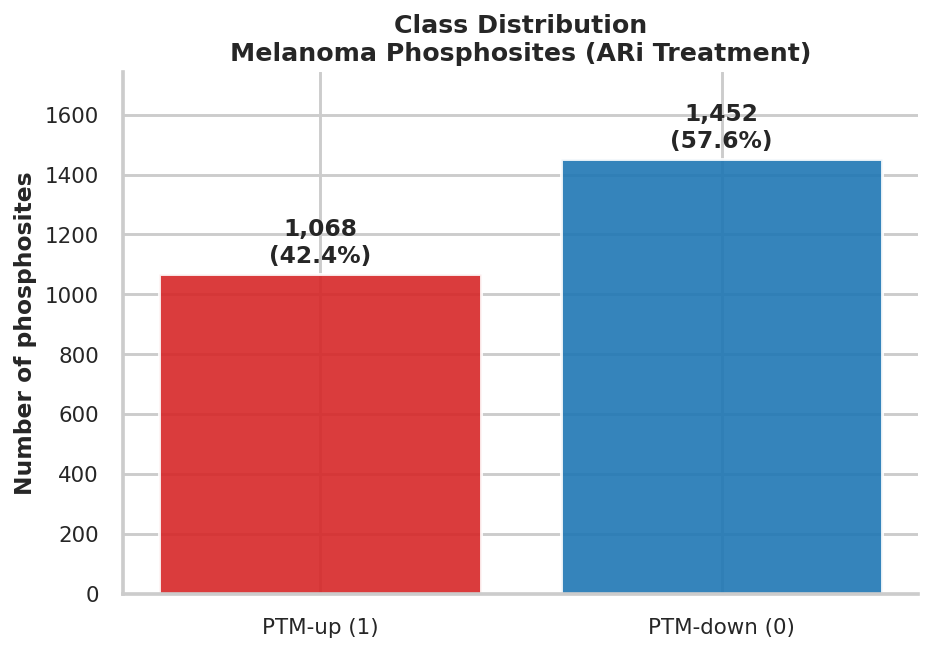

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/01_class_distribution.png


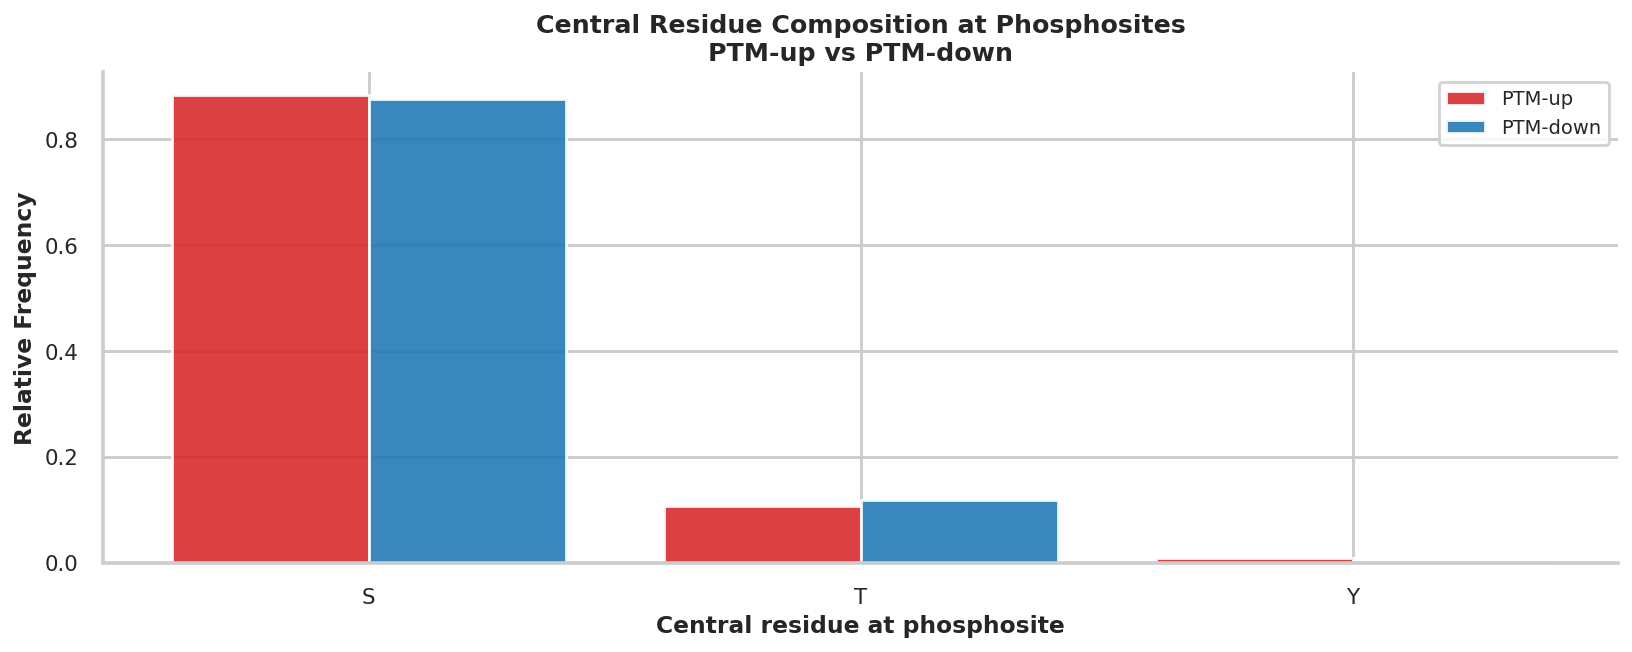

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/04_central_residue_composition.png


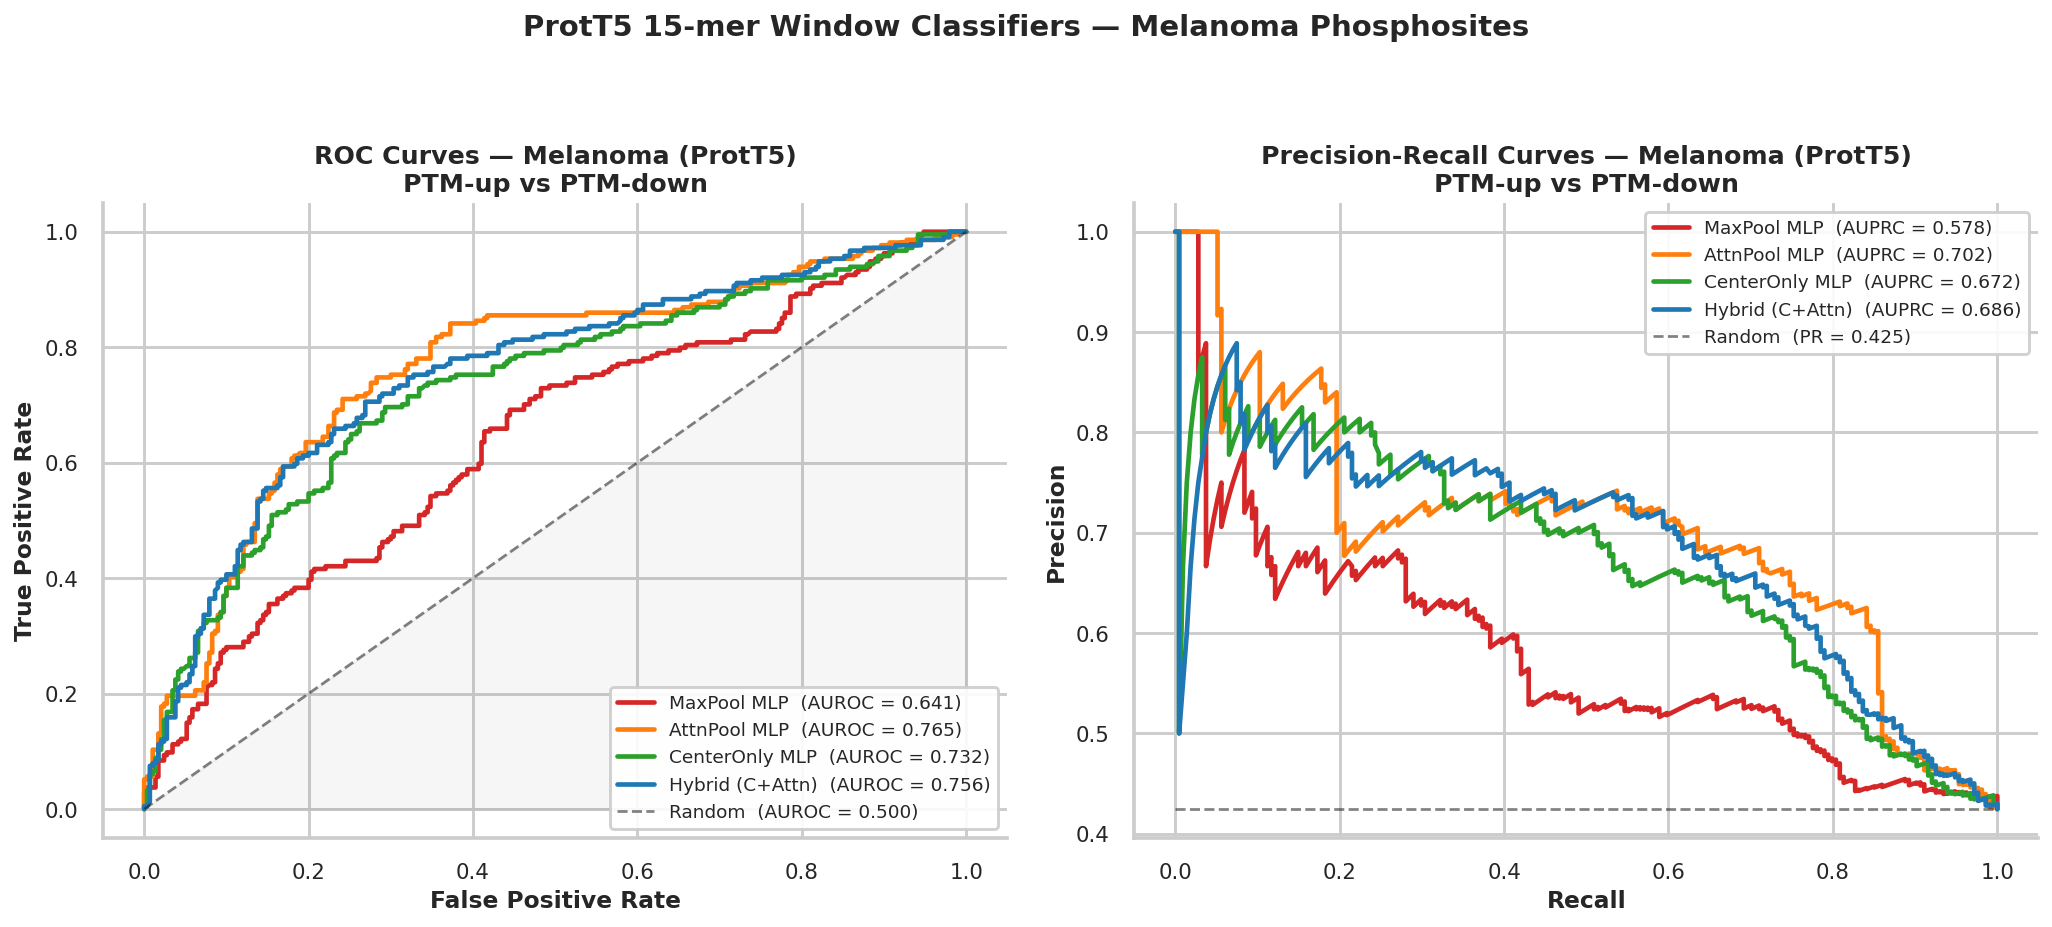

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/05_roc_pr_curves.png


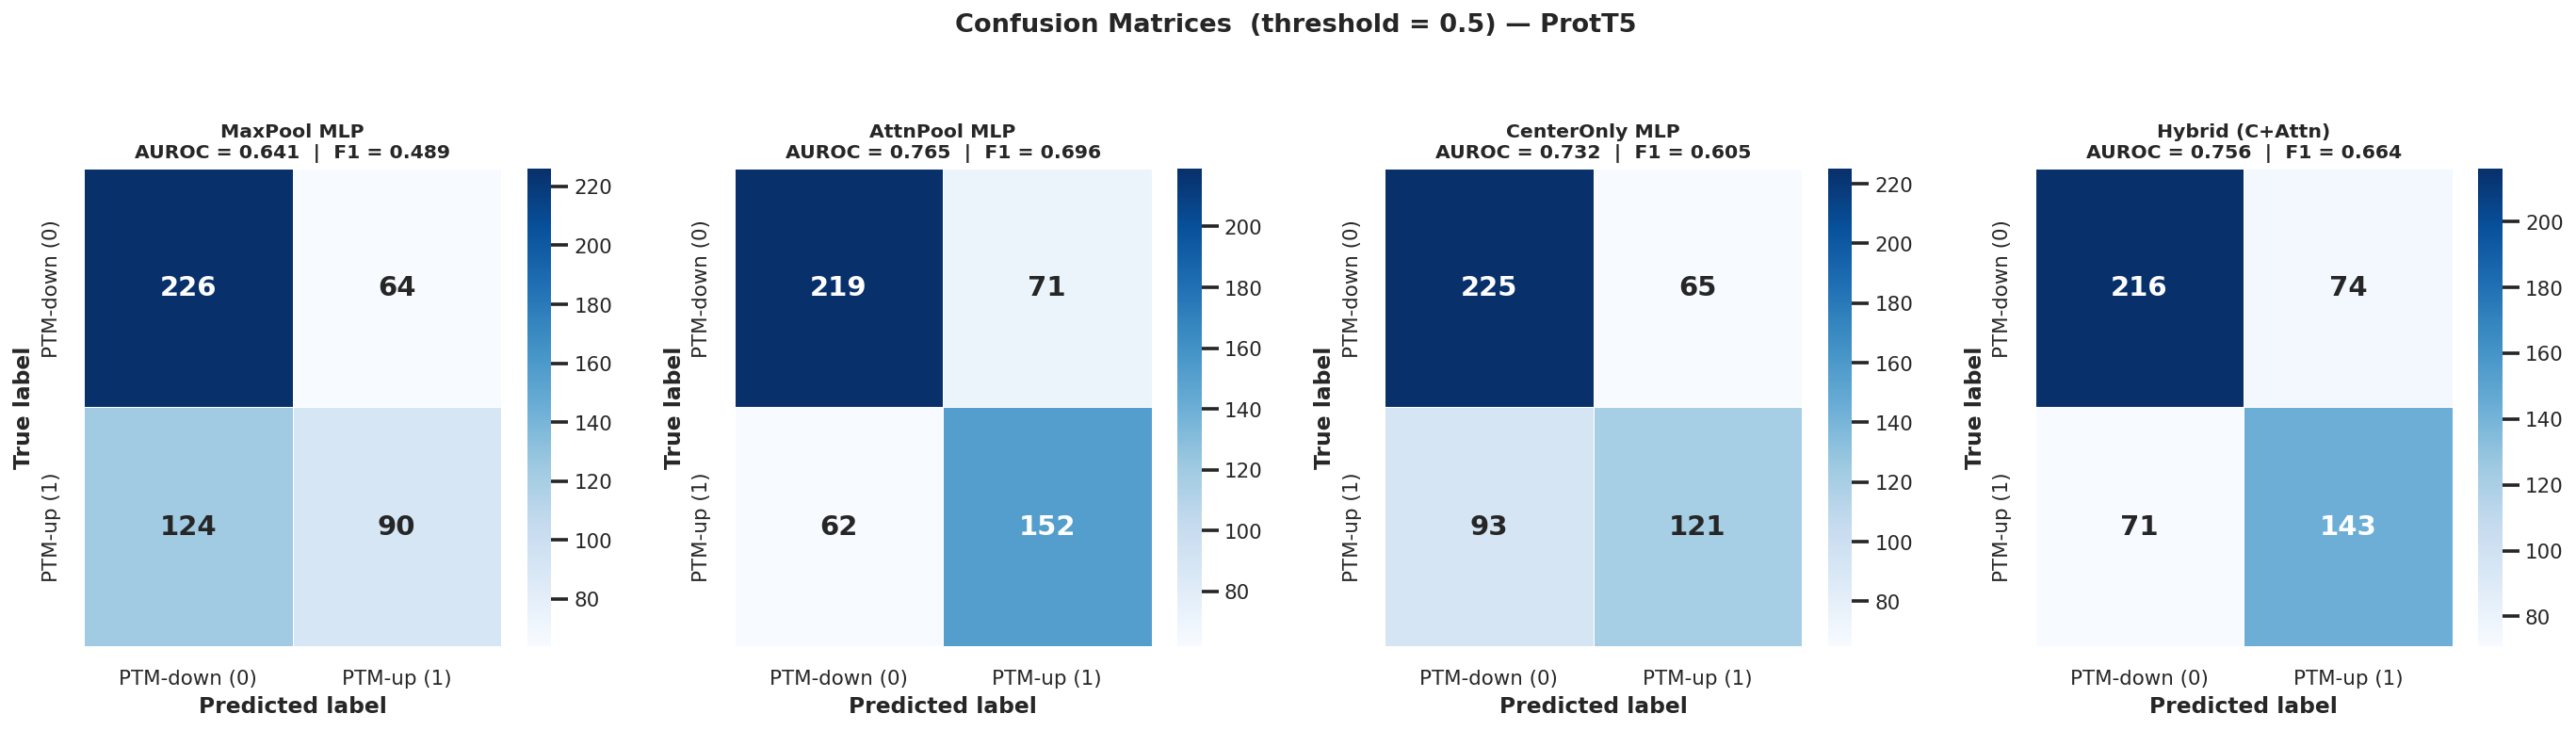

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/06_confusion_matrices.png


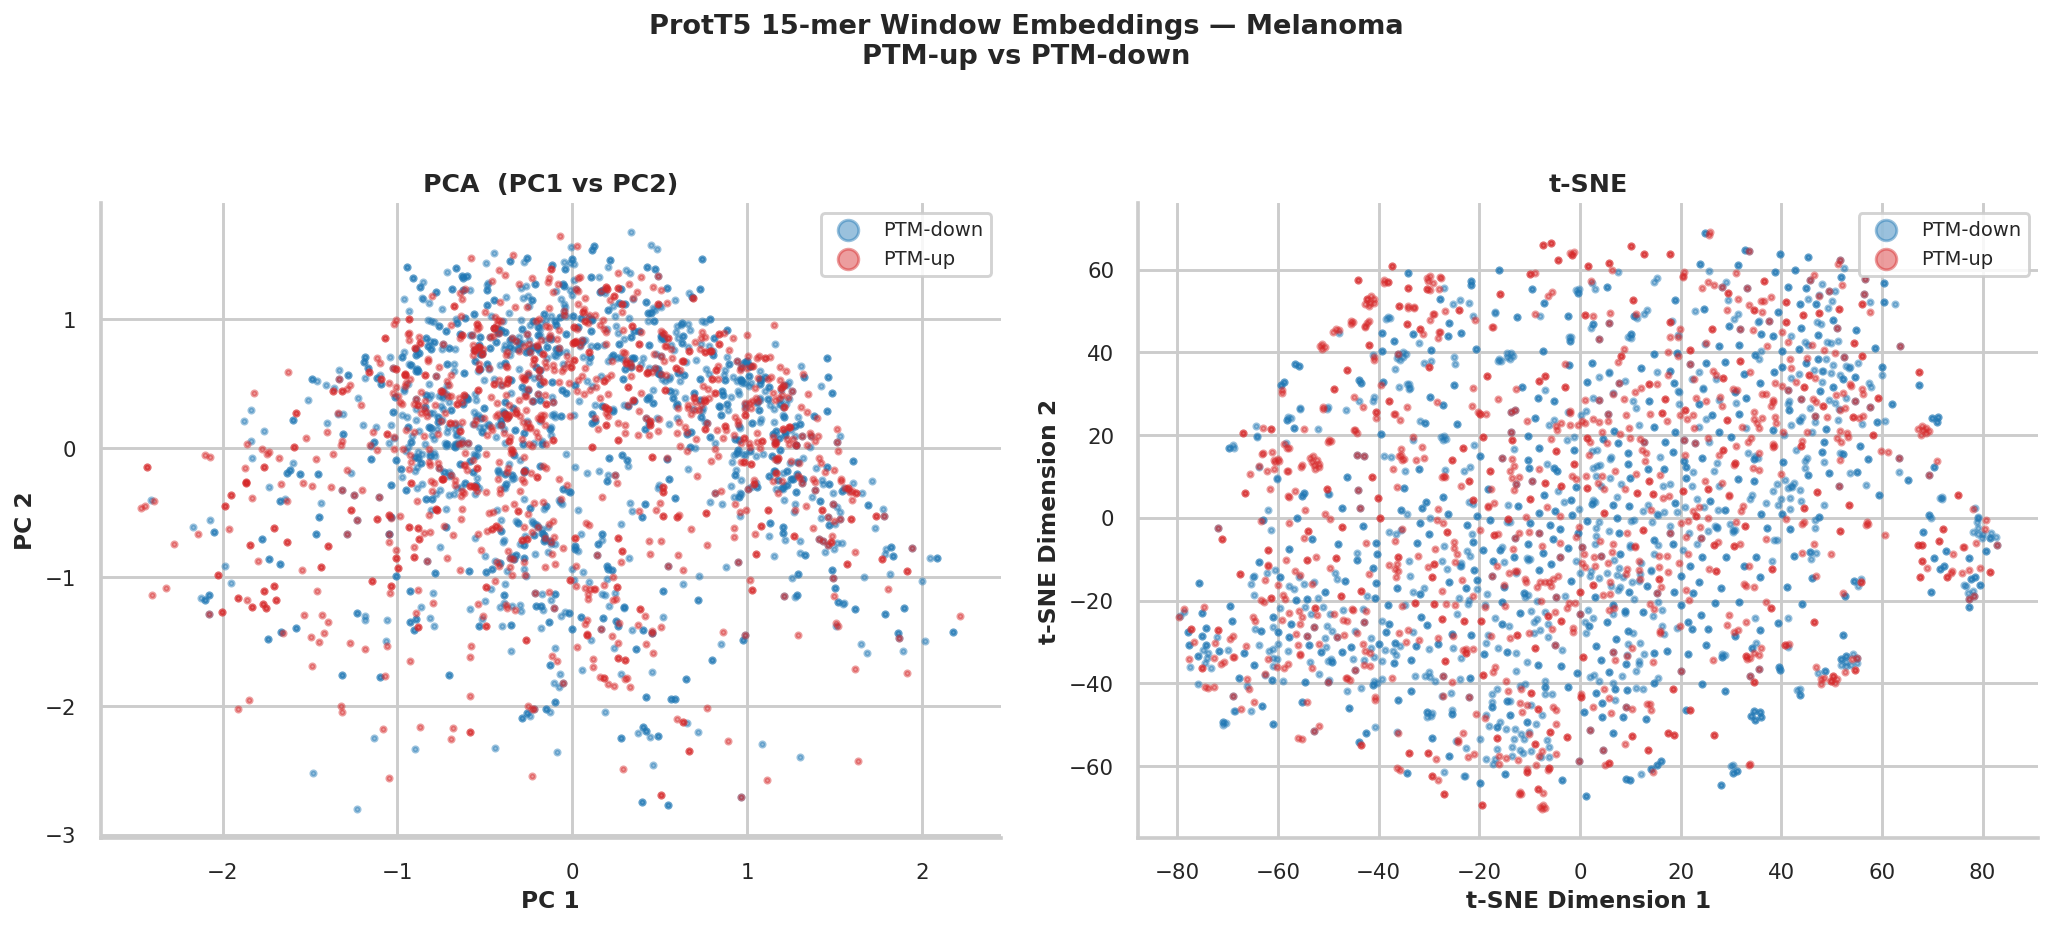

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/08_pca_tsne.png


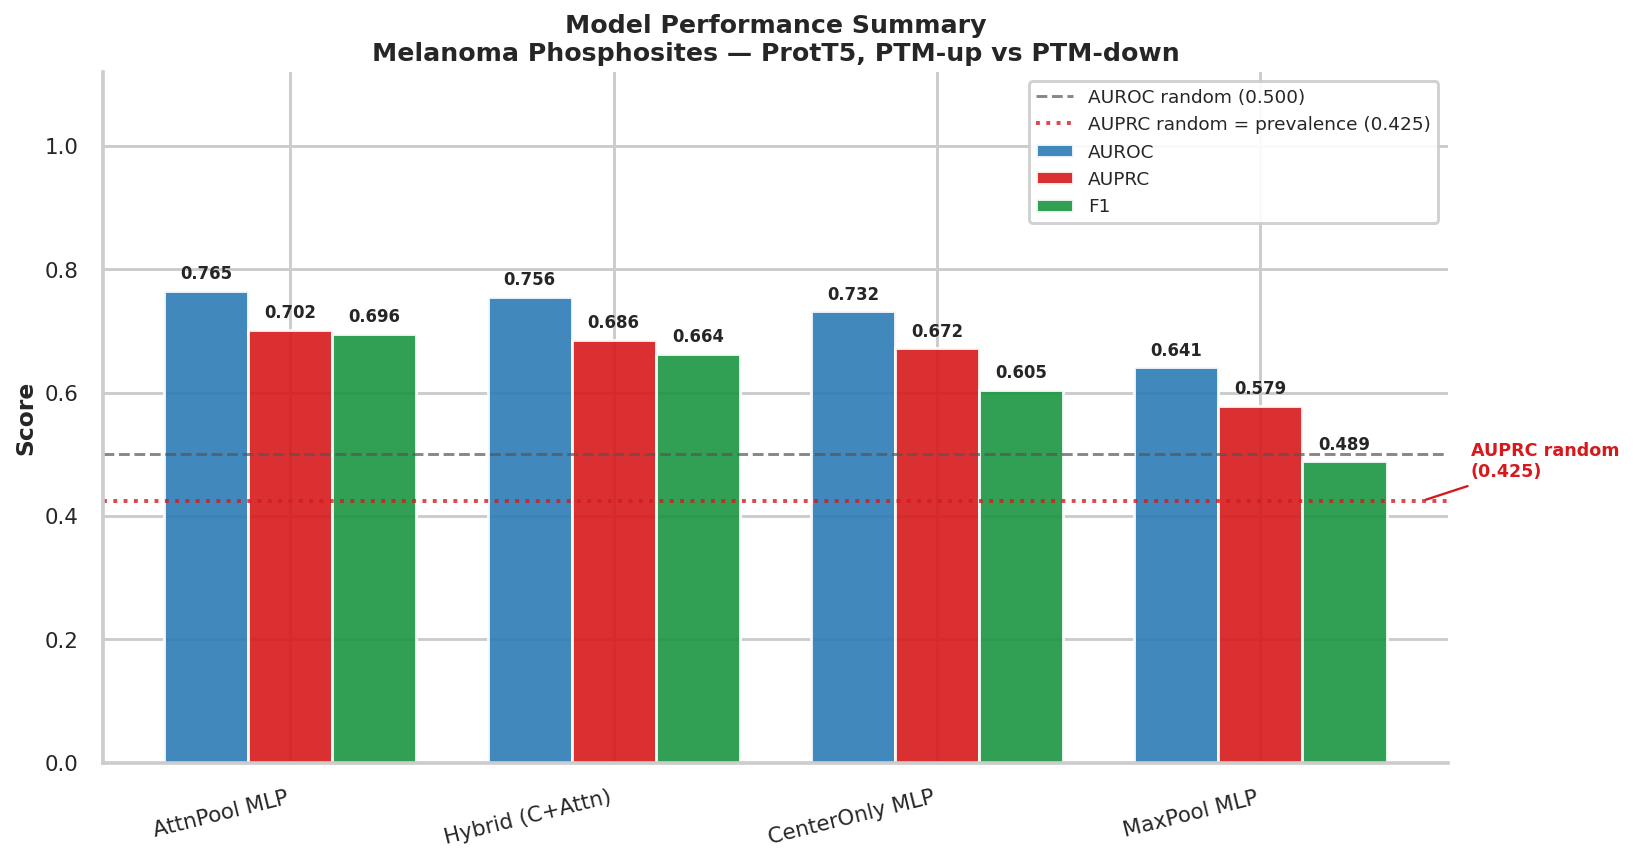

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/09_model_performance_summary.png


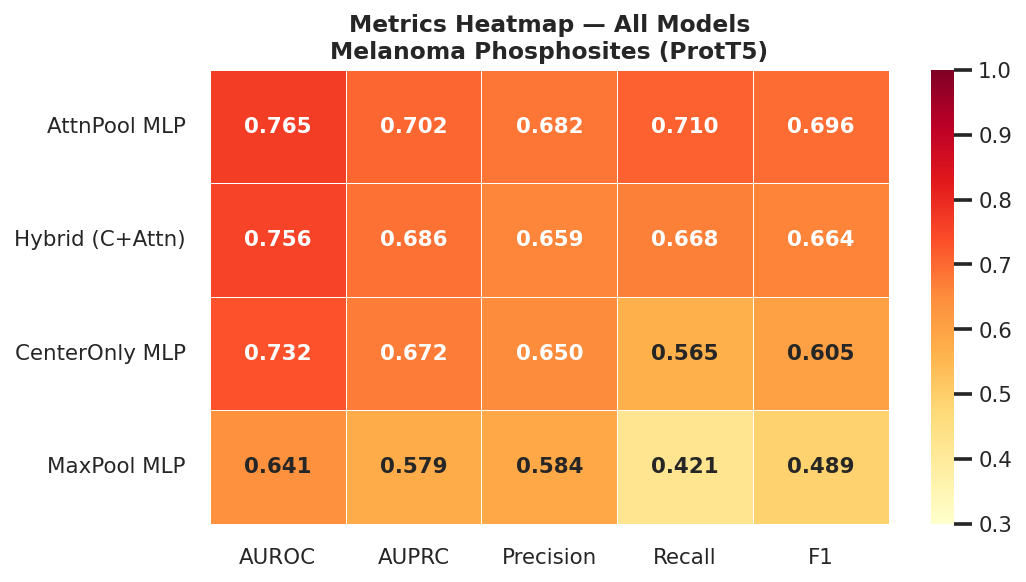

Saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/10_metrics_heatmap.png

  All publication figures saved to:
  /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# 6. PUBLICATION-GRADE FIGURES  (numbering mirrors EGFR reference pipeline)
#    01 class_distribution | 04 central_residue | 05 roc_pr | 06 confusion
#    07 model_metrics_summary.csv | 08 pca_tsne | 09 perf_bar | 10 heatmap
# ════════════════════════════════════════════════════════════════════════════
PALETTE4 = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]
RED, BLUE = "#d62728", "#1f77b4"

# ── 01. Class Distribution ────────────────────────────────────────────────────
n_up, n_down = int((y == 1).sum()), int((y == 0).sum())
cc = pd.DataFrame({"Class": ["PTM-up (1)", "PTM-down (0)"], "Count": [n_up, n_down]})
cc["Fraction"] = cc["Count"] / cc["Count"].sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(cc["Class"], cc["Count"], color=[RED, BLUE], alpha=0.90, edgecolor="white")
ax.set_ylabel("Number of phosphosites")
ax.set_title("Class Distribution\nMelanoma Phosphosites (ARi Treatment)")
ax.set_ylim(0, cc["Count"].max() * 1.20)
for i, row in cc.iterrows():
    ax.text(i, row["Count"] + cc["Count"].max() * 0.015,
            f'{row["Count"]:,}\n({row["Fraction"]:.1%})',
            ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '01_class_distribution.png'}")

# ── 04. Central Residue Composition ──────────────────────────────────────────
df_model["center_aa"] = df_model["Site_15mer"].apply(
    lambda s: str(s)[7] if isinstance(s, str) and len(s) >= 8
              and str(s)[7] not in ("_", "-") else None
)
df_up_m   = df_model[df_model["Class"] == 1].dropna(subset=["center_aa"])
df_down_m = df_model[df_model["Class"] == 0].dropna(subset=["center_aa"])
aas       = sorted(set(df_up_m["center_aa"]) | set(df_down_m["center_aa"]))
up_freq   = df_up_m["center_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)
down_freq = df_down_m["center_aa"].value_counts(normalize=True).reindex(aas, fill_value=0)

xp = np.arange(len(aas))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(xp - 0.2, up_freq.values,   0.4, label="PTM-up",   color=RED,  alpha=0.88, edgecolor="white")
ax.bar(xp + 0.2, down_freq.values, 0.4, label="PTM-down", color=BLUE, alpha=0.88, edgecolor="white")
ax.set_xticks(xp)
ax.set_xticklabels(aas)
ax.set_xlabel("Central residue at phosphosite")
ax.set_ylabel("Relative Frequency")
ax.set_title("Central Residue Composition at Phosphosites\nPTM-up vs PTM-down")
ax.legend(framealpha=0.85)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_central_residue_composition.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '04_central_residue_composition.png'}")

# ── 05. ROC + PR Curves ───────────────────────────────────────────────────────
baseline_pr = float((y_test == 1).mean())
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for (name, res), color in zip(results.items(), PALETTE4):
    fpr, tpr, _ = roc_curve(y_test, res["probs"])
    axes[0].plot(fpr, tpr, lw=2.4, color=color,
                 label=f"{name}  (AUROC = {res['roc_auc']:.3f})")
    prec_c, rec_c, _ = precision_recall_curve(y_test, res["probs"])
    axes[1].plot(rec_c, prec_c, lw=2.4, color=color,
                 label=f"{name}  (AUPRC = {res['pr_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1.4, alpha=0.55, label="Random  (AUROC = 0.500)")
axes[0].fill_between([0, 1], [0, 1], alpha=0.04, color="k")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Melanoma (ProtT5)\nPTM-up vs PTM-down")
axes[0].legend(loc="lower right", fontsize=9.5, framealpha=0.90)
axes[1].hlines(baseline_pr, 0, 1, linestyles="--", colors="k", lw=1.4, alpha=0.55,
               label=f"Random  (PR = {baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Melanoma (ProtT5)\nPTM-up vs PTM-down")
axes[1].legend(loc="upper right", fontsize=9.5, framealpha=0.90)
fig.suptitle("ProtT5 15-mer Window Classifiers — Melanoma Phosphosites",
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "05_roc_pr_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '05_roc_pr_curves.png'}")

# ── 06. Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, res), color in zip(axes, results.items(), PALETTE4):
    preds = (res["probs"] >= THRESHOLD).astype(int)
    cm    = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["PTM-down (0)", "PTM-up (1)"],
        yticklabels=["PTM-down (0)", "PTM-up (1)"],
        linewidths=0.5, linecolor="white",
        annot_kws={"size": 15, "weight": "bold"},
    )
    roc = res["roc_auc"]
    f1  = f1_score(y_test, preds, zero_division=0)
    ax.set_title(f"{name}\nAUROC = {roc:.3f}  |  F1 = {f1:.3f}", fontsize=10.5)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
fig.suptitle("Confusion Matrices  (threshold = 0.5) — ProtT5",
             fontsize=14, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "06_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '06_confusion_matrices.png'}")

# ── 08. PCA + t-SNE Embedding Visualisation ───────────────────────────────────
label_colors = {1: RED, 0: BLUE}
label_names  = {1: "PTM-up", 0: "PTM-down"}
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for label in [0, 1]:
    mask = y == label
    kw = dict(s=7, alpha=0.45, color=label_colors[label],
              label=label_names[label], rasterized=True)
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1], **kw)
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], **kw)
for ax, title, xl, yl in zip(
    axes,
    ["PCA  (PC1 vs PC2)", "t-SNE"],
    ["PC 1", "t-SNE Dimension 1"],
    ["PC 2", "t-SNE Dimension 2"],
):
    ax.set_title(title)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.legend(markerscale=4, framealpha=0.85)
fig.suptitle("ProtT5 15-mer Window Embeddings — Melanoma\nPTM-up vs PTM-down",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "08_pca_tsne.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '08_pca_tsne.png'}")

# ── 09. Model Performance Summary (grouped bar + baselines) ───────────────────
auprc_random = float((y_test == 1).mean())
mp   = metrics_df.set_index("Model")[["AUROC", "AUPRC", "F1"]].copy()
xpos = np.arange(len(mp))
w    = 0.26
fig, ax = plt.subplots(figsize=(12, 6.5))
b1 = ax.bar(xpos - w, mp["AUROC"], w, label="AUROC", color="#2c7bb6", alpha=0.90, edgecolor="white")
b2 = ax.bar(xpos,     mp["AUPRC"], w, label="AUPRC", color="#d7191c", alpha=0.90, edgecolor="white")
b3 = ax.bar(xpos + w, mp["F1"],    w, label="F1",    color="#1a9641", alpha=0.90, edgecolor="white")
ax.axhline(0.500,        ls="--", lw=1.5, color="#555555", alpha=0.70,
           label="AUROC random (0.500)")
ax.axhline(auprc_random, ls=":",  lw=2.0, color="#d7191c", alpha=0.80,
           label=f"AUPRC random = prevalence ({auprc_random:.3f})")
ax.annotate(f"AUPRC random\n({auprc_random:.3f})",
            xy=(len(mp) - 0.5, auprc_random),
            xytext=(len(mp) - 0.35, auprc_random + 0.04),
            fontsize=9, color="#d7191c", fontweight="bold",
            arrowprops=dict(arrowstyle="-", color="#d7191c", lw=1.2))
ax.set_xticks(xpos)
ax.set_xticklabels(mp.index, rotation=14, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title("Model Performance Summary\nMelanoma Phosphosites — ProtT5, PTM-up vs PTM-down")
ax.legend(loc="upper right", framealpha=0.90, fontsize=9.5)
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.013,
                f"{bar.get_height():.3f}", ha="center", va="bottom",
                fontsize=8.5, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "09_model_performance_summary.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '09_model_performance_summary.png'}")

# ── 10. Metrics Heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.5))
hm_data = metrics_df.set_index("Model")[["AUROC", "AUPRC", "Precision", "Recall", "F1"]]
sns.heatmap(
    hm_data, annot=True, fmt=".3f", cmap="YlOrRd",
    vmin=0.3, vmax=1.0, linewidths=0.5, linecolor="white",
    annot_kws={"size": 11, "weight": "bold"}, ax=ax,
)
ax.set_title("Metrics Heatmap — All Models\nMelanoma Phosphosites (ProtT5)", fontsize=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "10_metrics_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {RESULTS_DIR / '10_metrics_heatmap.png'}")

print(f"\n{'='*60}")
print(f"  All publication figures saved to:")
print(f"  {RESULTS_DIR}")
print(f"{'='*60}")


In [11]:
# ── HTML Summary Report (mirrors EGFR reference pipeline) ────────────────────
import base64


def img_to_b64(path: Path) -> str:
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    return f'<img src="data:image/png;base64,{data}" style="max-width:100%;"/>'


plot_files   = sorted(RESULTS_DIR.glob("*.png"))
metrics_html = metrics_df.to_html(index=False, border=1,
                                   classes="metrics", justify="center")

html_parts = [
    f"""<!DOCTYPE html>
<html><head>
<meta charset='utf-8'/>
<title>ProtT5 Phospho Melanoma — Analysis Report</title>
<style>
  body {{ font-family: Arial, sans-serif; max-width: 1100px; margin: auto; padding: 20px; }}
  h1   {{ color: #1a3c34; }}
  h2   {{ color: #2c3e50; border-bottom: 2px solid #ccc; padding-bottom: 4px; }}
  table.metrics {{ border-collapse: collapse; width: 100%; }}
  table.metrics th, table.metrics td {{ border: 1px solid #aaa; padding: 8px 14px; text-align: center; }}
  table.metrics th {{ background-color: #1a3c34; color: white; }}
  .plot-grid {{ display: flex; flex-wrap: wrap; gap: 16px; }}
  .plot-grid figure {{ margin: 0; text-align: center; }}
</style>
</head><body>
<h1>ProtT5 Melanoma Phosphorylation Classifier</h1>
<h2>Dataset: Melanoma Cells — ARi Treatment (PTM-up vs PTM-down)</h2>
<p><b>PTM-up (1):</b> {n_up} sites &nbsp;|&nbsp; <b>PTM-down (0):</b> {n_down} sites</p>
<p><b>Model:</b> ProtT5-XL-UniRef50 ({EMBED_DIM}-dim) · 15-residue context window around phosphosite</p>
<hr/>
<h2>Model Performance Summary</h2>
""",
    metrics_html,
    "<hr/>\n<h2>Plots</h2>\n<div class='plot-grid'>\n",
]

for p in plot_files:
    html_parts.append(f"<figure>{img_to_b64(p)}<figcaption>{p.name}</figcaption></figure>\n")

html_parts.append("</div></body></html>")

report_path = RESULTS_DIR / "report_phospho_prott5.html"
report_path.write_text("".join(html_parts), encoding="utf-8")
print(f"HTML report saved → {report_path}")


HTML report saved → /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5/report_phospho_prott5.html


In [12]:
# ── Final Summary vs Random Baseline ─────────────────────────────────────────
random_auroc = 0.500
random_prauc = float((y_test == 1).mean())

print("=" * 60)
print("FINAL RESULTS — ProtT5 | Melanoma PTM-up vs PTM-down")
print("=" * 60)
print(f"Embedder : ProtT5-XL-UniRef50  ({EMBED_DIM}-dim)")
print(f"Samples  : {len(X)} total  |  PTM-up: {(y==1).sum()}  PTM-down: {(y==0).sum()}")
print(f"Split    : 80% train / 20% test, stratified")
print()
print(f"Random baselines (test):  AUROC = {random_auroc:.4f}  |  AUPRC = {random_prauc:.4f}")
print()
print(f"{'Model':<22} {'AUROC':>7} {'ΔAUROC':>8} {'AUPRC':>7} {'ΔAUPRC':>8} {'F1':>7}")
print("-" * 65)
for _, row in metrics_df.iterrows():
    print(f"{row['Model']:<22} {row['AUROC']:>7.4f} "
          f"{row['AUROC']-random_auroc:>+8.4f} "
          f"{row['AUPRC']:>7.4f} "
          f"{row['AUPRC']-random_prauc:>+8.4f} "
          f"{row['F1']:>7.4f}")
print()
best = metrics_df.iloc[0]
print(f"Best model : {best['Model']}")
print(f"  AUROC  = {best['AUROC']:.4f}  (Δ vs random = {best['AUROC']-random_auroc:+.4f})")
print(f"  AUPRC  = {best['AUPRC']:.4f}  (Δ vs random = {best['AUPRC']-random_prauc:+.4f})")
print(f"  F1     = {best['F1']:.4f}")
print()
print(f"Outputs saved to: {RESULTS_DIR.resolve()}")
for f in sorted(RESULTS_DIR.iterdir()):
    print(f"  {f.name}")

FINAL RESULTS — ProtT5 | Melanoma PTM-up vs PTM-down
Embedder : ProtT5-XL-UniRef50  (1024-dim)
Samples  : 2520 total  |  PTM-up: 1068  PTM-down: 1452
Split    : 80% train / 20% test, stratified

Random baselines (test):  AUROC = 0.5000  |  AUPRC = 0.4246

Model                    AUROC   ΔAUROC   AUPRC   ΔAUPRC      F1
-----------------------------------------------------------------
AttnPool MLP            0.7654  +0.2654  0.7021  +0.2775  0.6957
Hybrid (C+Attn)         0.7560  +0.2560  0.6863  +0.2617  0.6636
CenterOnly MLP          0.7321  +0.2321  0.6719  +0.2473  0.6050
MaxPool MLP             0.6410  +0.1410  0.5785  +0.1539  0.4891

Best model : AttnPool MLP
  AUROC  = 0.7654  (Δ vs random = +0.2654)
  AUPRC  = 0.7021  (Δ vs random = +0.2775)
  F1     = 0.6957

Outputs saved to: /home/saishyam/Protein_dynamics/Dynamic_properties/PDMAS_drug_response/Melanoma_Phosphorylation_PDMAS_Ari_FUT4_OE/results_melanoma_phospho_prott5
  01_class_distribution.png
  04_central_residue_composit